# 03 — Гибридная нейросетевая архитектура (первая итерация)

Концептуальная модель диссертации: раздельная обработка разнородной информации + явное моделирование временной динамики.

**Архитектура `HybridSurvivalNet`** (`src/recidivism/hybrid.py`):

1. **Статическая ветвь (MLP)** — неизменные во времени признаки: демография, криминальная история, атрибуты приговора (40 признаков).
2. **Динамическая ветвь (MLP)** — признаки периода надзора: нарушения, наркотесты, занятость, посещение программ (23 признака).
3. **Управляемое слияние (gated fusion)** — обучаемый гейт взвешивает вклад каждой ветви.
4. **Временная голова (GRU, discrete-time survival)** — слитое представление инициализирует GRU, развёрнутую на 3 годовых шага; каждый шаг выдаёт *hazard* — условную вероятность первого ареста в году *t*:

$$P(\text{рецидив за 3 года}) = 1 - \prod_{t=1}^{3} (1 - h_t)$$

В отличие от бинарных бейзлайнов, сеть обучается на погодовых метках (`Recidivism_Arrest_Year1/2/3`) и учится предсказывать не только *произойдёт ли* рецидив, но и *когда* риск реализуется.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from recidivism.data import prepare_nij
from recidivism.metrics import classification_metrics
from recidivism.train import train_hybrid, train_mlp

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

data = prepare_nij("../data/raw/nij_recidivism_full.csv")
print("static:", len(data.static_cols), "| dynamic:", len(data.dynamic_cols))

static: 40 | dynamic: 23


In [2]:
# Обучение нейросетевого бейзлайна (MLP) и гибридной survival-сети
mlp, mlp_info = train_mlp(data.X_train, data.y_train, seed=42)
print(f"\nMLP best val AUC: {mlp_info['best_val_auc']:.4f}\n")

hybrid, hyb_info = train_hybrid(
    data.X_train, data.y_years_train, data.static_cols, data.dynamic_cols, seed=42)
print(f"\nHybrid best val AUC: {hyb_info['best_val_auc']:.4f}")

epoch   1 | loss 0.5963 | val AUC 0.7716


epoch   5 | loss 0.5234 | val AUC 0.7934


epoch  10 | loss 0.5019 | val AUC 0.7957


epoch  15 | loss 0.4863 | val AUC 0.7975


epoch  20 | loss 0.4717 | val AUC 0.7960


...

epoch  20 | loss 1.0049 | val AUC 0.8012


epoch  25 | loss 0.9899 | val AUC 0.8014


epoch  30 | loss 0.9759 | val AUC 0.8007


epoch  35 | loss 0.9670 | val AUC 0.8019



Hybrid best val AUC: 0.8029


In [3]:
# Сравнение с классическими бейзлайнами (результаты scripts/run_experiments.py)
p_mlp = mlp.predict_proba_1d(data.X_test)
p_hyb = hybrid.predict_proba_1d(data.X_test)

nn_rows = [
    {"model": "mlp", **classification_metrics(data.y_test, p_mlp)},
    {"model": "hybrid_survival", **classification_metrics(data.y_test, p_hyb)},
]
nn_df = pd.DataFrame(nn_rows).set_index("model")

baseline_df = pd.read_csv("../results/metrics_nij.csv", index_col="model")
comparison = pd.concat([baseline_df.drop(index=[i for i in nn_df.index if i in baseline_df.index]), nn_df])
comparison = comparison.sort_values("roc_auc", ascending=False)
comparison.round(4)

,roc_auc,f1,accuracy,precision,recall,brier,ece
model,,,,,,,
xgboost,0.8196,0.7913,0.7491,0.7573,0.8285,0.1688,0.0202
hybrid_survival,0.8086,0.7842,0.7405,0.7505,0.8211,0.1736,0.0267
random_forest,0.8051,0.7911,0.7395,0.7330,0.8592,0.1780,0.0518
mlp,0.8028,0.7814,0.7359,0.7445,0.8222,0.1766,0.0208
logreg,0.7898,0.7784,0.7313,0.7392,0.8220,0.1812,0.0151


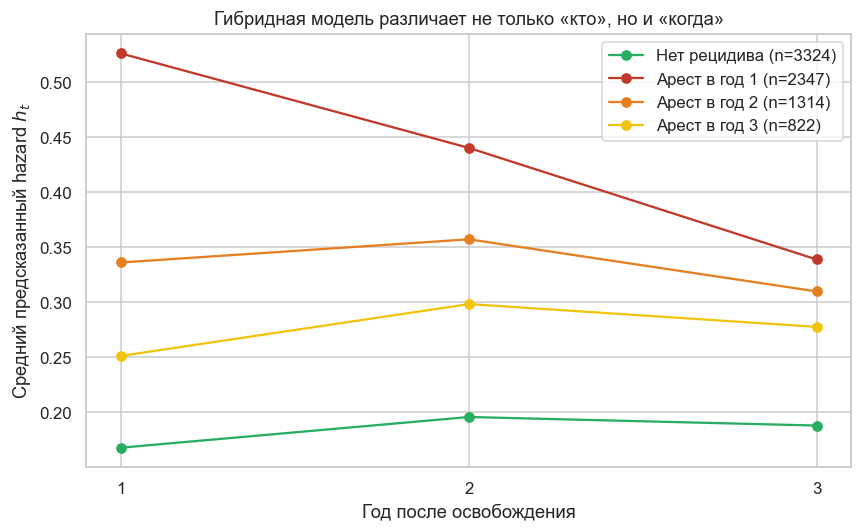

In [4]:
# Временная структура риска: средние hazard по годам для разных исходов
hazards = hybrid.predict_hazards(data.X_test)  # (n, 3)

first_year = np.where(data.y_years_test.sum(axis=1) > 0,
                      data.y_years_test.argmax(axis=1) + 1, 0)

fig, ax = plt.subplots(figsize=(8, 5))
labels = {0: "Нет рецидива", 1: "Арест в год 1", 2: "Арест в год 2", 3: "Арест в год 3"}
colors = {0: "#27ae60", 1: "#c0392b", 2: "#e67e22", 3: "#f1c40f"}
for k, lbl in labels.items():
    mask = first_year == k
    ax.plot([1, 2, 3], hazards[mask].mean(axis=0), marker="o", label=f"{lbl} (n={mask.sum()})", color=colors[k])
ax.set_xticks([1, 2, 3])
ax.set_xlabel("Год после освобождения")
ax.set_ylabel("Средний предсказанный hazard $h_t$")
ax.set_title("Гибридная модель различает не только «кто», но и «когда»")
ax.legend()
plt.tight_layout()
plt.show()

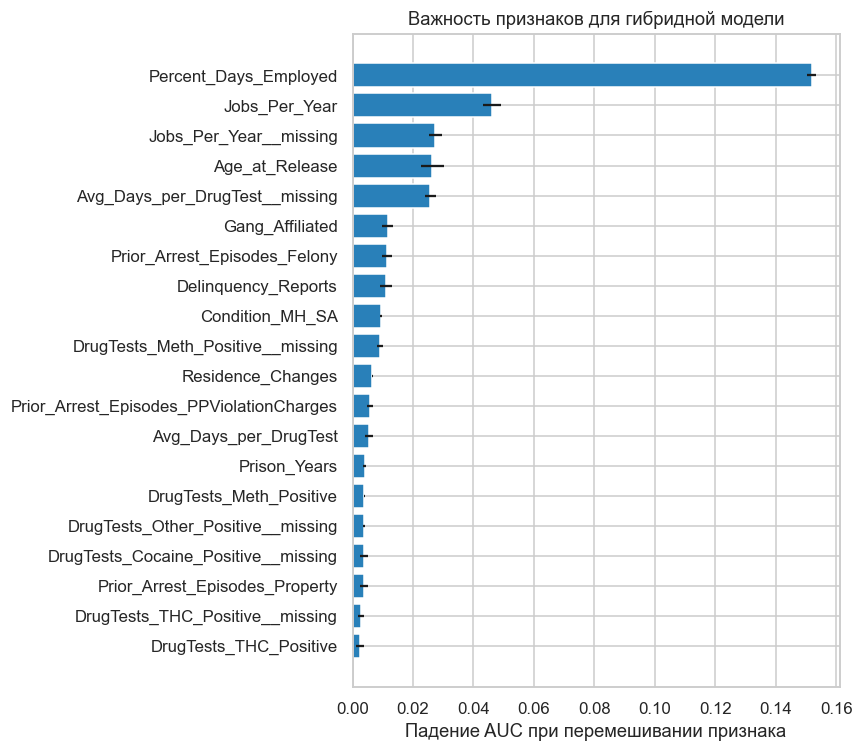

,feature,auc_drop_mean,auc_drop_std
0,Percent_Days_Employed,0.151852,0.001547
1,Jobs_Per_Year,0.046039,0.002903
2,Jobs_Per_Year__missing,0.027423,0.002075
3,Age_at_Release,0.026401,0.003728
4,Avg_Days_per_DrugTest__missing,0.025765,0.001905
5,Gang_Affiliated,0.011595,0.001820
6,Prior_Arrest_Episodes_Felony,0.011490,0.001728
7,Delinquency_Reports,0.011129,0.001953
8,Condition_MH_SA,0.009461,0.000311
9,DrugTests_Meth_Positive__missing,0.009135,0.000905


In [5]:
# Интерпретируемость гибридной сети: permutation importance (падение AUC)
from recidivism.explain import permutation_importance

imp = permutation_importance(hybrid.predict_proba_1d, data.X_test, data.y_test,
                             n_repeats=3, max_samples=3000)

plt.figure(figsize=(8, 7))
top = imp.head(20).iloc[::-1]
plt.barh(top["feature"], top["auc_drop_mean"], xerr=top["auc_drop_std"], color="#2980b9")
plt.xlabel("Падение AUC при перемешивании признака")
plt.title("Важность признаков для гибридной модели")
plt.tight_layout()
plt.show()
imp.head(10)